In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("2 loan_approval_data.csv")

In [4]:
df.head()
df.describe()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

# Handle missing values

In [5]:
categorical_cols = df.select_dtypes(include=["str"]).columns
numerical_cols = df.select_dtypes(include=["float64"]).columns


In [6]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='str')

In [7]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])


cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [8]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA- exploratory data analysis

([<matplotlib.patches.Wedge at 0x21c94234d70>,
 [Text(-0.6521425375337495, 0.8858386482531919, 'no'),
  Text(0.6521428261765839, -0.8858384357581341, 'yes')],
 [Text(-0.3557141113820451, 0.48318471722901374, '70.2%'),
  Text(0.3557142688235912, -0.4831846013226186, '29.8%')])

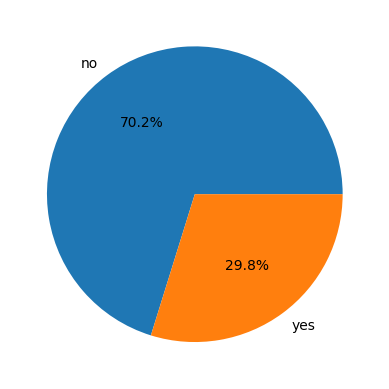

In [9]:
## how balaced our classes are?
clases_count=df["Loan_Approved"].value_counts()
plt.pie(clases_count, labels=["no","yes"], autopct="%1.1f%%")

[Text(0, 0, '621'), Text(0, 0, '379')]

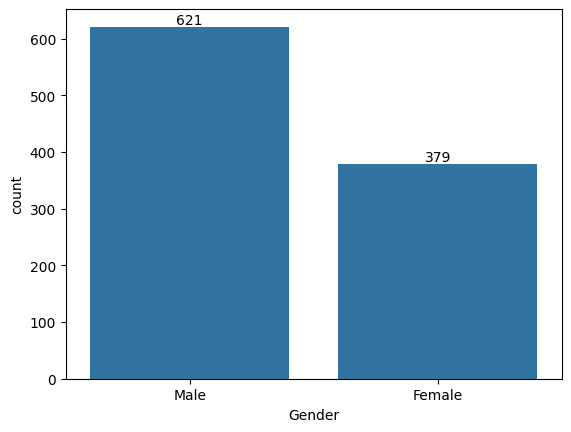

In [10]:
## analyze categories
gender_count=df["Gender"].value_counts()
ax = sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

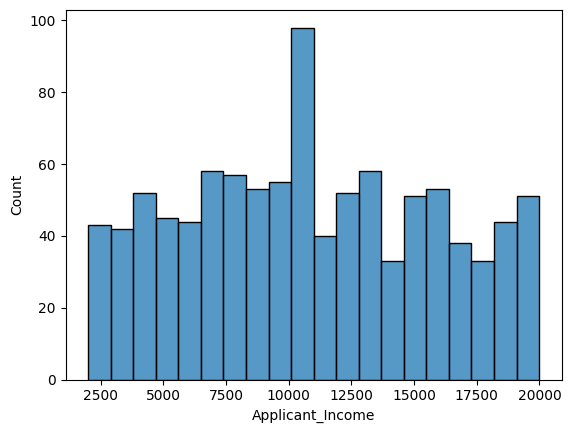

In [11]:
## analyze income
sns.histplot(
    data=df,
    x= "Applicant_Income",
    bins =20,
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

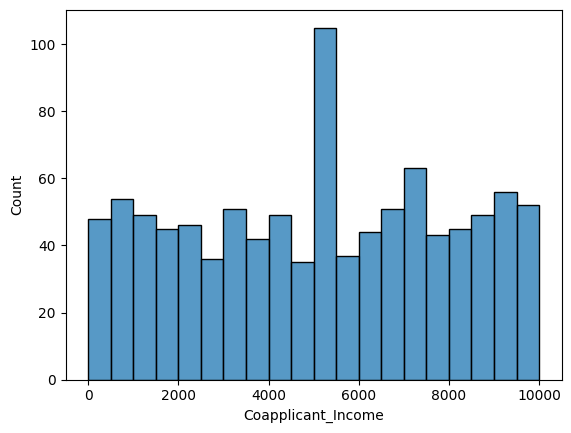

In [14]:
sns.histplot(
    data=df,
    x= "Coapplicant_Income",
    bins =20,
)

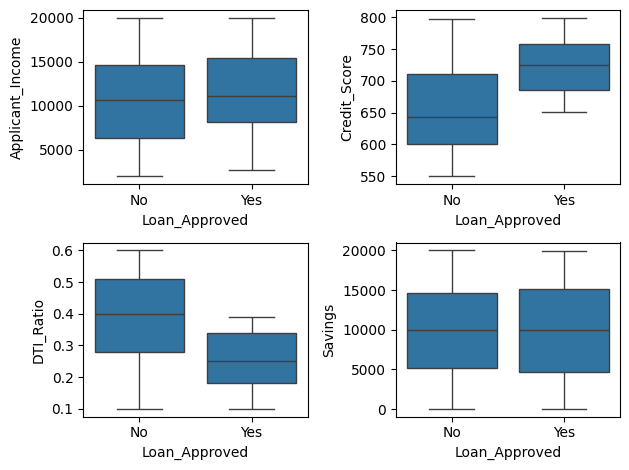

In [15]:
fig, axes = plt.subplots(2,2)

sns.boxplot(ax=axes[0,0], data=df , x="Loan_Approved" , y="Applicant_Income")
sns.boxplot(ax=axes[0,1], data=df , x="Loan_Approved" , y="Credit_Score")
sns.boxplot(ax=axes[1,0], data=df , x="Loan_Approved" , y="DTI_Ratio")
sns.boxplot(ax=axes[1,1], data=df , x= "Loan_Approved" , y="Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

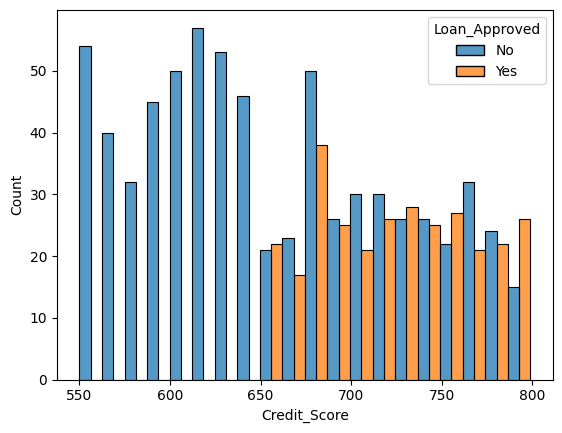

In [16]:
## credit score and load approved
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [17]:
df.head()


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# Endcoding

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   str    
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   str    
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   str    
 15  Property_Area       1000 non-null   str    
 16  Education_Level   

In [19]:
from sklearn.preprocessing import LabelEncoder ,OneHotEncoder
le = LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])


In [20]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [21]:
cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category" ]

Ohe = OneHotEncoder(drop="first", sparse_output=False ,handle_unknown='ignore')
encoded = Ohe.fit_transform(df[cols])

In [22]:
encoded_df = pd.DataFrame(encoded,columns=Ohe.get_feature_names_out(cols),index=df.index)
df = pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [23]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


# correlation heatmap

<Axes: >

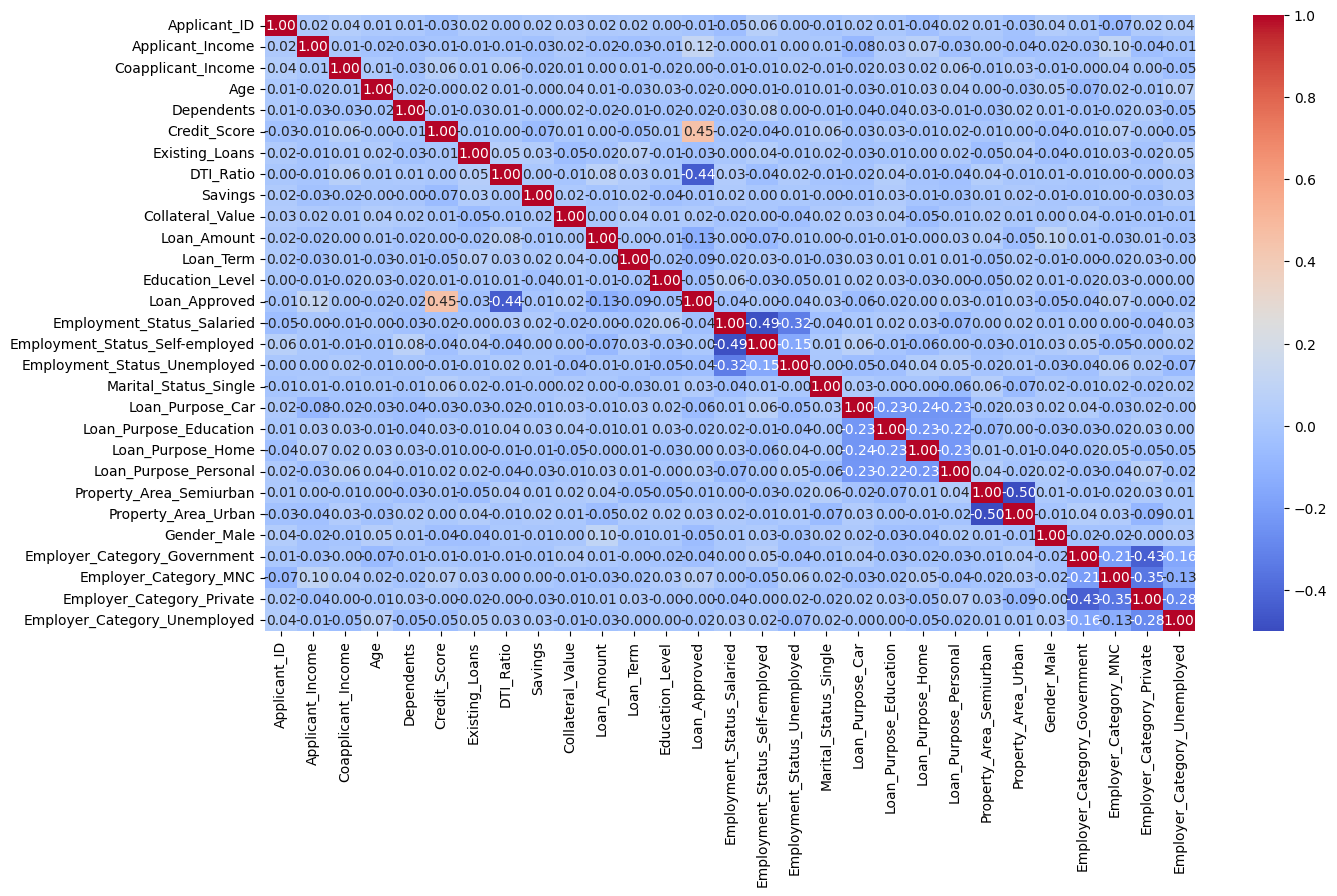

In [27]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)


In [28]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Applicant_ID                      -0.011167
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed    

# `Train-Test-Split and Feature scaling`

In [30]:
X = df.drop("Loan_Approved", axis=1 )
y = df["Loan_Approved"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and Evaluate model

Logistic regression

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


log_model = LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation

print("precision: ", precision_score(y_test,y_pred))
print("recall: ", recall_score(y_test,y_pred))
print("f1 score: ", f1_score(y_test,y_pred))
print("accuracy: ", accuracy_score(y_test,y_pred))
print("cm: ", confusion_matrix(y_test,y_pred))

precision:  0.7868852459016393
recall:  0.7868852459016393
f1 score:  0.7868852459016393
accuracy:  0.87
cm:  [[126  13]
 [ 13  48]]


In [35]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)

y_pred = knn_model.predict(X_test_scaled)

print("precision: ", precision_score(y_test,y_pred))
print("recall: ", recall_score(y_test,y_pred))
print("f1 score: ", f1_score(y_test,y_pred))
print("accuracy: ", accuracy_score(y_test,y_pred))
print("cm: ", confusion_matrix(y_test,y_pred))


precision:  0.5957446808510638
recall:  0.45901639344262296
f1 score:  0.5185185185185185
accuracy:  0.74
cm:  [[120  19]
 [ 33  28]]


In [37]:
# naive byes
from sklearn.naive_bayes import GaussianNB

bayes_model = GaussianNB()
bayes_model.fit(X_train_scaled,y_train)

y_pred = bayes_model.predict(X_test_scaled)

print("precision: ", precision_score(y_test,y_pred))
print("recall: ", recall_score(y_test,y_pred))
print("f1 score: ", f1_score(y_test,y_pred))
print("accuracy: ", accuracy_score(y_test,y_pred))
print("cm: ", confusion_matrix(y_test,y_pred))

precision:  0.8035714285714286
recall:  0.7377049180327869
f1 score:  0.7692307692307693
accuracy:  0.865
cm:  [[128  11]
 [ 16  45]]


# feature engineering

In [ ]:
# add and transform features
df["DTI_Ratio_sq"] = df["DTI_Ratio"] **2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

# use of log for squing for squed data - squed data where data is in large amount at one side
#df["Applicant_Income_log"]= np.log1p(df["Applicant_Income"])

X = df.drop(columns=["Loan_Approved", "Credit_Score","DTI_Ratio"])
y = df["Loan_Approved"]

# train test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation

print("precision: ", precision_score(y_test,y_pred))
print("recall: ", recall_score(y_test,y_pred))
print("f1 score: ", f1_score(y_test,y_pred))
print("accuracy: ", accuracy_score(y_test,y_pred))
print("cm: ", confusion_matrix(y_test,y_pred))

precision:  0.7846153846153846
recall:  0.8360655737704918
f1 score:  0.8095238095238095
accuracy:  0.88
cm:  [[125  14]
 [ 10  51]]


In [42]:
bayes_model = GaussianNB()
bayes_model.fit(X_train_scaled,y_train)

y_pred = bayes_model.predict(X_test_scaled)

print("precision: ", precision_score(y_test,y_pred))
print("recall: ", recall_score(y_test,y_pred))
print("f1 score: ", f1_score(y_test,y_pred))
print("accuracy: ", accuracy_score(y_test,y_pred))
print("cm: ", confusion_matrix(y_test,y_pred))

precision:  0.8076923076923077
recall:  0.6885245901639344
f1 score:  0.7433628318584071
accuracy:  0.855
cm:  [[129  10]
 [ 19  42]]
